# Summary: Clustering Method Comparison Across All Datasets

Aggregates results from `01_wine.ipynb`, `02_mall_customers.ipynb`,
`03_fashion_mnist.ipynb`, and `04_make_moons.ipynb` (each writes its metrics
to `results/<dataset>_results.csv`).

**Run the other 4 notebooks first** so `results/*.csv` exist before running
this one.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sc4020 import viz

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 50)

RESULTS_DIR = Path("../results")
DATASETS = ["wine", "mall_customers", "fashion_mnist", "make_moons"]

In [2]:
frames = []
for name in DATASETS:
    path = RESULTS_DIR / f"{name}_results.csv"
    if not path.exists():
        print(f"missing {path} - run {name}'s notebook first")
        continue
    frames.append(pd.read_csv(path))
all_results = pd.concat(frames, ignore_index=True)
all_results.head()

,dataset,method,fit_seconds,param_n_clusters,n_clusters_found,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,adjusted_rand_index,normalized_mutual_info,adjusted_mutual_info,fowlkes_mallows,param_eps,param_min_samples,param_min_cluster_size,param_n_components,param_affinity
0,wine,KMeans++,0.023319,3.0,3,0.000000,0.284859,1.389188,70.940008,0.897495,0.875894,0.874579,0.931908,NaN,NaN,NaN,NaN,NaN
1,wine,DBSCAN,0.001358,NaN,2,0.646067,0.422757,0.916156,53.194265,0.305801,0.475611,0.469266,0.593746,2.08269,10.0,NaN,NaN,NaN
2,wine,HDBSCAN,0.001671,NaN,2,0.387640,0.359409,1.052838,60.978669,0.262971,0.359656,0.352616,0.525818,NaN,NaN,8.0,NaN,NaN
3,wine,GMM,0.030834,NaN,3,0.000000,0.284859,1.389188,70.940008,0.897495,0.875894,0.874579,0.931908,NaN,NaN,NaN,3.0,NaN
4,wine,Spectral Clustering,0.083037,3.0,3,0.000000,0.248553,1.271282,36.866444,0.444569,0.572465,0.566164,0.697882,NaN,NaN,NaN,NaN,rbf


## Combined metrics table

One row per (dataset, method). Mall Customers has no external metrics
(ARI/NMI/AMI/FMI are `NaN`) since it has no ground truth.

In [3]:
metric_cols = [
    "dataset", "method", "fit_seconds", "n_clusters_found", "noise_ratio",
    "silhouette", "davies_bouldin", "calinski_harabasz",
    "adjusted_rand_index", "normalized_mutual_info", "adjusted_mutual_info", "fowlkes_mallows",
]
display(all_results[metric_cols].sort_values(["dataset", "method"]))

,dataset,method,fit_seconds,n_clusters_found,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,adjusted_rand_index,normalized_mutual_info,adjusted_mutual_info,fowlkes_mallows
11,fashion_mnist,DBSCAN,0.011124,2,0.331667,0.161152,1.181886,79.305788,0.033155,0.100480,0.098648,0.268403
13,fashion_mnist,GMM,2.798608,10,0.000000,0.132121,2.036679,357.739297,0.390900,0.564763,0.562097,0.461480
12,fashion_mnist,HDBSCAN,0.303220,28,0.708667,0.228471,1.123200,125.893645,0.050307,0.330494,0.312532,0.283414
10,fashion_mnist,KMeans++,0.079439,10,0.000000,0.202065,1.470169,531.890855,0.343308,0.512117,0.509138,0.416696
14,fashion_mnist,Spectral Clustering,0.178743,10,0.000000,0.193616,1.567921,494.232337,0.398326,0.586044,0.583500,0.469193
16,make_moons,DBSCAN,0.004443,2,0.009000,0.392346,1.012962,872.064603,0.982066,0.959843,0.959785,0.990983
18,make_moons,GMM,0.067627,2,0.000000,0.495147,0.811785,1379.219134,0.489489,0.390213,0.389772,0.744497
17,make_moons,HDBSCAN,0.013070,2,0.027000,0.409269,0.969207,931.859499,0.946676,0.904251,0.904121,0.972947
15,make_moons,KMeans++,0.026500,2,0.000000,0.495011,0.811856,1379.803922,0.481117,0.382784,0.382337,0.740312
19,make_moons,Spectral Clustering,0.014513,2,0.000000,0.387472,1.023266,861.968496,1.000000,1.000000,1.000000,1.000000


## Metric comparison charts

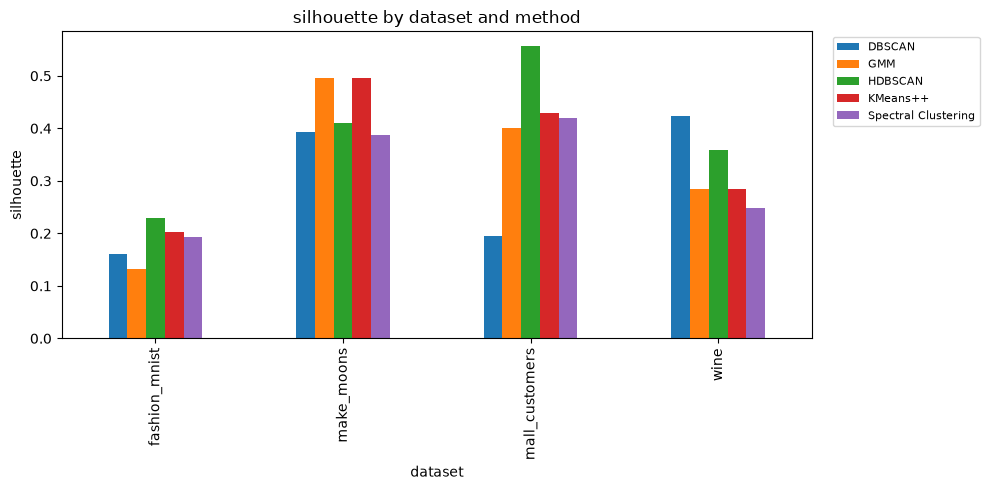

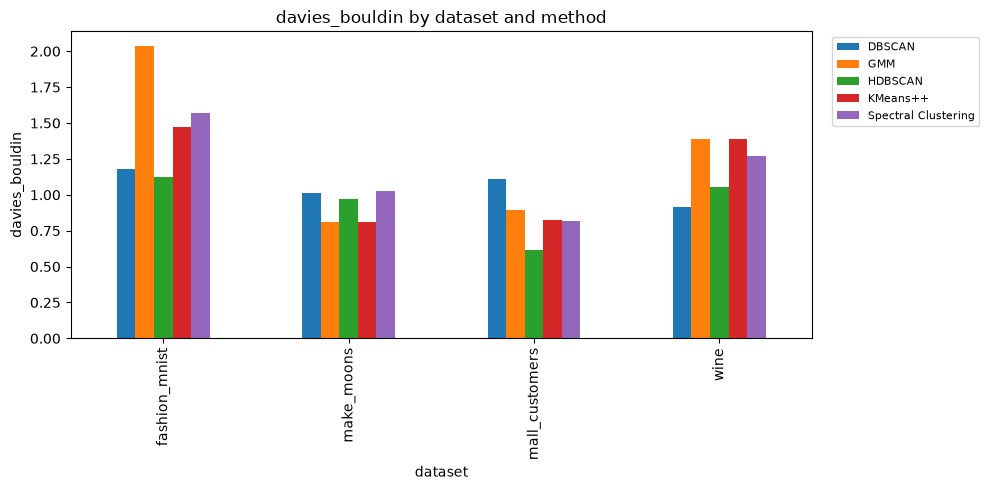

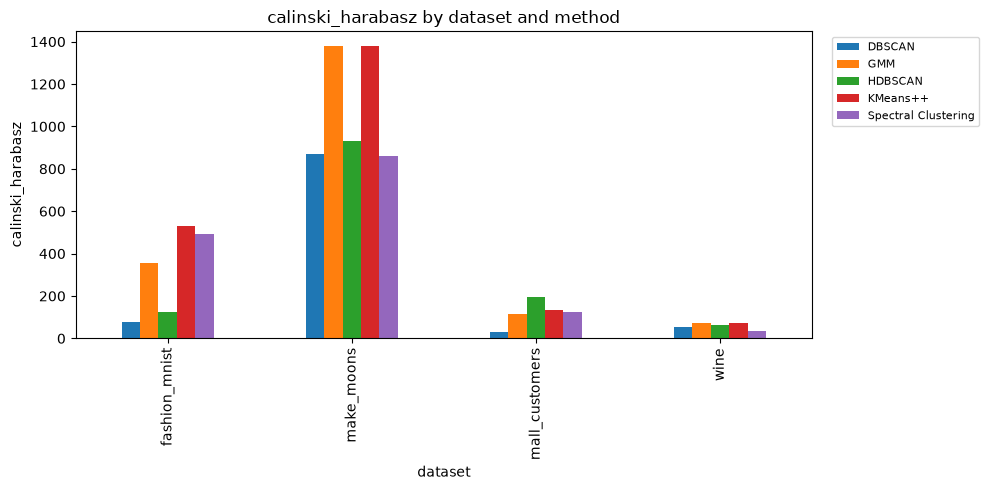

In [4]:
for metric in ["silhouette", "davies_bouldin", "calinski_harabasz"]:
    viz.plot_metrics_bar(all_results, metric)
    plt.show()

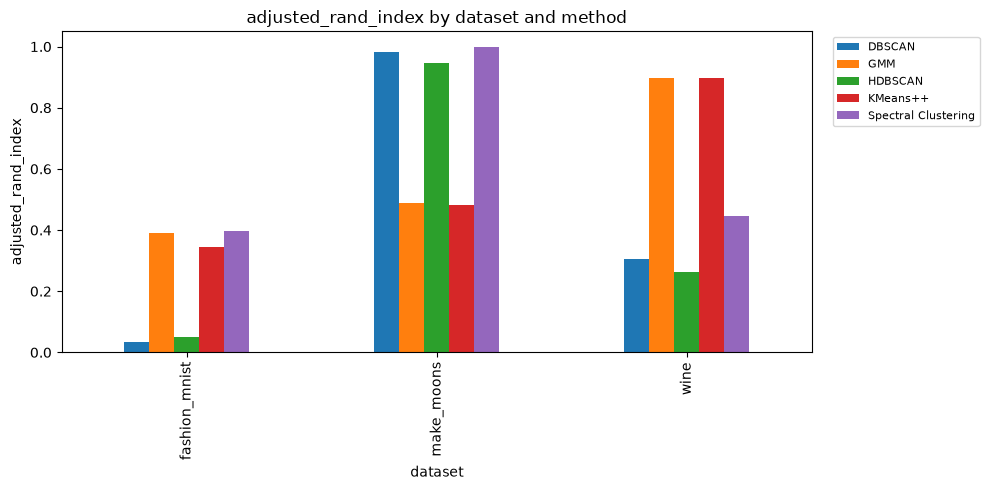

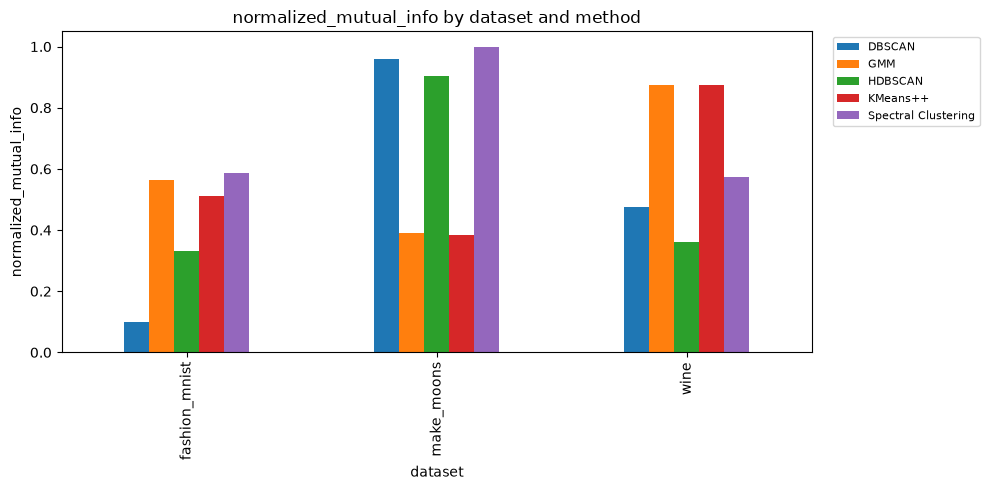

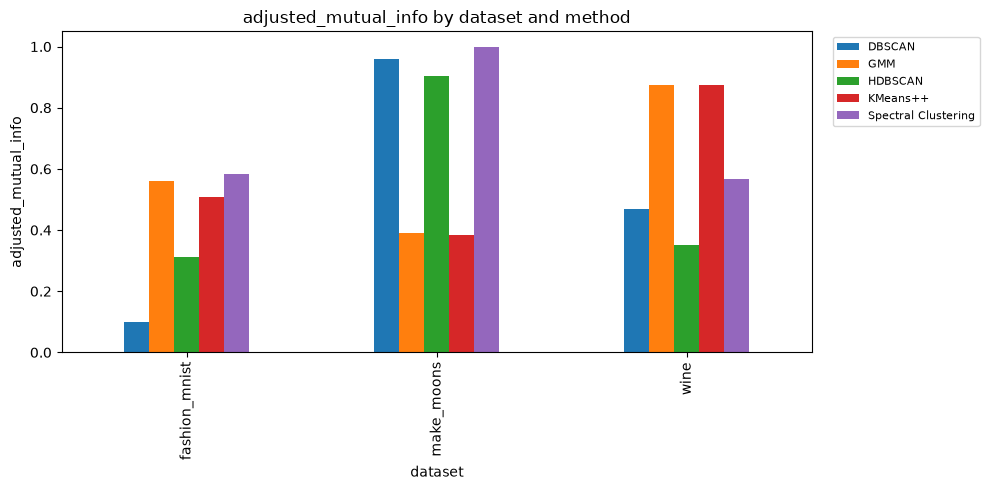

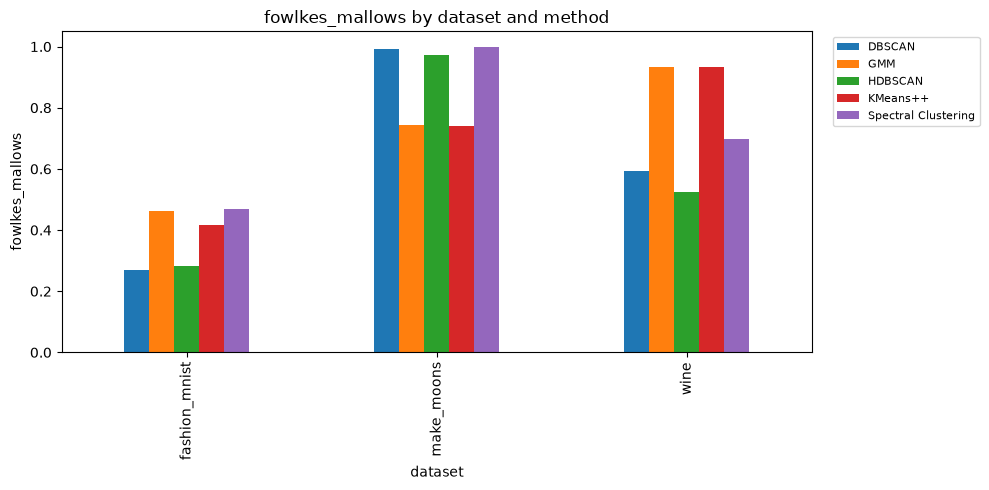

In [5]:
external_df = all_results.dropna(subset=["adjusted_rand_index"])
for metric in ["adjusted_rand_index", "normalized_mutual_info", "adjusted_mutual_info", "fowlkes_mallows"]:
    viz.plot_metrics_bar(external_df, metric)
    plt.show()

## Runtime comparison (proposed metric)

`fit_seconds` — wall-clock fit time — is reported as a first-class metric
throughout. It captures a dimension the required metrics don't: how each
method's cost scales with `n`/dimensionality, which is directly why
Fashion-MNIST needed subsampling for Spectral/DBSCAN/HDBSCAN in the first
place.

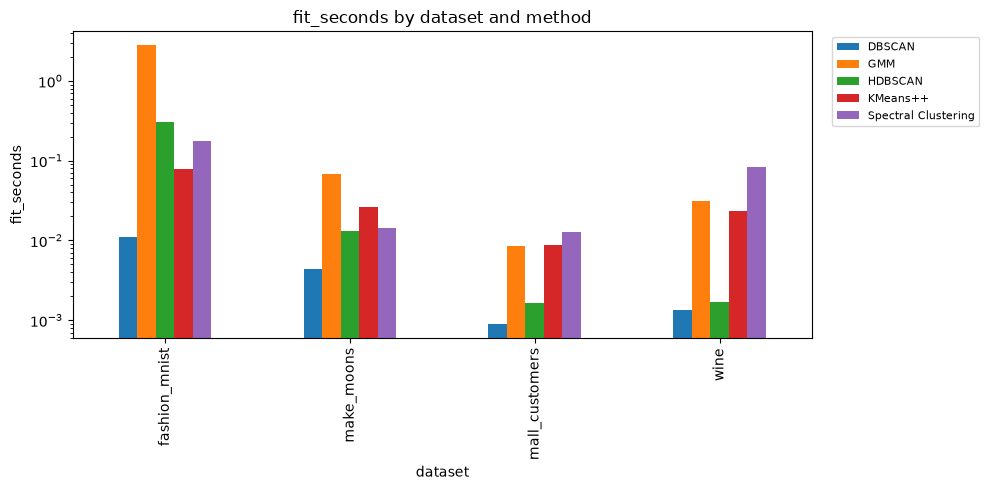

In [6]:
viz.plot_metrics_bar(all_results, "fit_seconds", log_scale=True)
plt.show()

## Findings

- **No single method wins everywhere.** K-Means++ and GMM are fast and strong
  when clusters are roughly convex/Gaussian and K is known (Wine), but fail
  badly on non-convex structure (make_moons).
- **DBSCAN and HDBSCAN win decisively on non-convex, well-separated data**
  (make_moons: ARI/NMI near 1.0) but are noticeably weaker in higher-dimensional
  or noisier feature spaces (Wine's 13-D space, Fashion-MNIST's 50-D PCA space),
  where a single global density threshold struggles — visible in their elevated
  `noise_ratio` and mismatched `n_clusters_found`.
- **Spectral Clustering** is the most consistently competitive method across
  shapes (convex and non-convex alike) when given an appropriate affinity
  (`rbf` for globular data, `nearest_neighbors` for manifold-shaped data), at
  the cost of being the slowest method (`fit_seconds`) and requiring K upfront.
- **Mall Customers** (no ground truth) is a reminder that internal metrics
  alone can't confirm a clustering is "correct" — only that it's internally
  well-separated; different methods here favor different segment counts/shapes
  with no way to declare a winner without domain judgment.
- **Proposed metrics beyond the required set** — Adjusted Mutual Information
  (chance-corrected, robust when predicted vs. true cluster counts differ, as
  with DBSCAN/HDBSCAN), Fowlkes-Mallows Index (pairwise precision/recall,
  complements ARI), noise ratio / clusters-found (diagnostic context for
  density-based methods), and fit time (practical scalability) — all added
  signal that Silhouette/DB/CH/ARI/NMI alone didn't capture in this comparison.